# Full Model & Standardisation

We will now fit the full model on our example dataset.

In [1]:
import numpy as np
import pandas as pd
import anndata
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import PIL

#import cytovanni

import sys
local_path = os.path.expanduser("~/cytovanni_publish/Cytovanni/src")
if local_path not in sys.path:
    sys.path.insert(0, local_path)
import cytovanni
cytovanni.__version__

'1.1.0'

In [2]:
raw_data_path = os.path.expanduser("~/Cytovanni/data/example_variable-spectra/")
data_path = os.path.expanduser("~/Cytovanni/docs/tutorials/integration_variable-spectra/")

We strongly suggest using a GPU for speedup. Our model can also be fit without a GPU, and torch will use all available CPU cores. However, it would need more than 80 CPU cores to achieve the same speed as a reasonable GPU, so we strongly suggest running it on a machine with GPU support.

In [3]:
import torch
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(device)

cuda:0


In [4]:
cytoconfig = cytovanni.utils.CytometerConfiguration_A3()

## Data

First, we need to load the training and test data, apply a rough gating, and add all the relevant metadata.

Some metadata:
- ovlp_uid is an identifier shared across aliquots, and all samples that share the same identifier should ideally look identical
- is_train is our assignment whether a sample should be used for the training or not. Note that the assignment is not simply random, as we need enough overlap on every day for markers that are not present in the reference sample to integrate all relevant markers.

In [6]:
meta_reference = pd.read_table(os.path.join(data_path, "calibrated_fcs", "meta_ReferenceOverlap.csv"), sep=",", index_col=0)
meta_sample = pd.read_table(os.path.join(data_path, "calibrated_fcs", "meta_SamplesOverlap.csv"), sep=",", index_col=0)
meta_sample.head()

,filepath,sample,sample_id,batch_rb,m_date,batch_ref,fileregex,panel,batch,m_month,m_year,begin_record,begin_record_s,batch_ref_iidx,ovlp_uid,is_train
0,HD7_202303/2_HD7Tcell20230329/Batch D_1573.fcs,20230329_tcell_D_1573,1573,20230329_tcell_D,20230329,20230329_tcell_D,HD7_202303/[1-9]_HD7Tcell20230329/Batch D_([0-...,tcell,20230329_tcell_D,202303,2023,16:00:55,57655,30,IS_1573,False
1,HD7_202404/HD7tcell20240418/Batch A_2157.fcs,20240418_tcell_A_2157,2157,20240418_tcell_A,20240418,20240418_tcell_A,HD7_202404/HD7tcell20240418/Batch A_([0-9]+).fcs,tcell,20240418_tcell_A,202404,2024,11:40:24,42024,4,IS_1573,False
2,HD7_202303/4_HD7Tcell20230331/Batch C_1956.fcs,20230331_tcell_C_1956,1956,20230331_tcell_C,20230331,20230331_tcell_C,HD7_202303/[1-9]_HD7Tcell20230331/Batch C_([0-...,tcell,20230331_tcell_C,202303,2023,13:57:34,50254,28,IS_1956,False
3,HD7_202404/HD7tcell20240418/Batch A_2187.fcs,20240418_tcell_A_2187,2187,20240418_tcell_A,20240418,20240418_tcell_A,HD7_202404/HD7tcell20240418/Batch A_([0-9]+).fcs,tcell,20240418_tcell_A,202404,2024,12:20:43,44443,34,IS_1956,False
4,HD7_202303/3_HD7Tcell20230330/Batch C_1749.fcs,20230330_tcell_C_1749,1749,20230330_tcell_C,20230330,20230330_tcell_C,HD7_202303/[1-9]_HD7Tcell20230330/Batch C_([0-...,tcell,20230330_tcell_C,202303,2023,14:46:43,53203,31,IS_1749,True


We need some rough gates.

In [8]:
# a broad cell gate
gate_cells = cytovanni.gating.PolygonGate("FSC-A", "SSC-A", np.asarray([[6e4,1.5e4],[8e4,1.3e4],[1.35e5,5e4],[1.35e5,.9e5],[.9e5,.9e5],[.7e5,4.5e4]]),
                                          name="single cells", layer="raw", color="black")
# simple doublet gates
gate_nd_SSC = cytovanni.gating.PolygonGate("SSC-A", "SSC-H", np.asarray([[1.5e4,.5e4],[1e4,1.5e4],[1e5,1e5],[1e5,7e4]]),
                                           name="not doublet, SSC", layer="raw", color="green")
gate_nd_FSC = cytovanni.gating.PolygonGate("FSC-A", "FSC-H", np.asarray([[6e4,4e4],[5.5e4,6e4],[1.4e5,1.3e5],[1.4e5,10e4]]),
                                           name="not doublet, FSC", layer="raw", color="green")

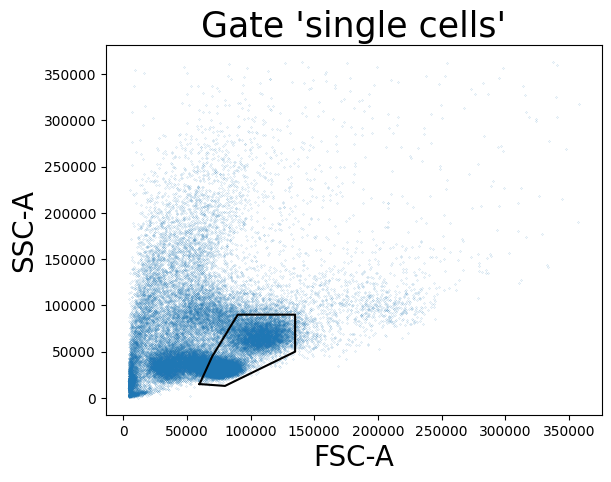

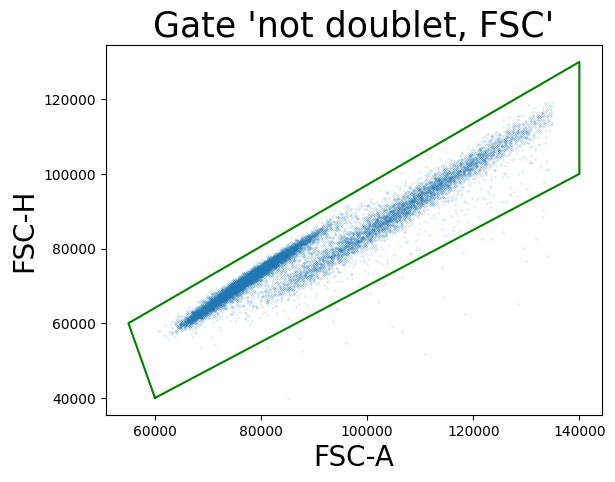

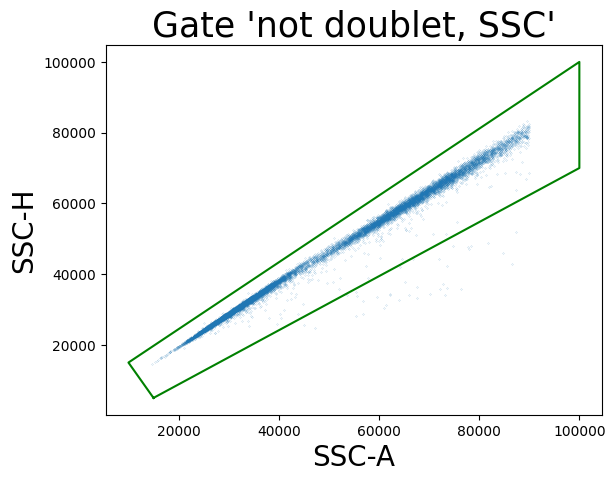

In [9]:
adata = cytovanni.io.readfcs_sample(os.path.join(data_path, "calibrated_fcs", meta_reference.iloc[10]["filepath"]),
                                    cytoconfig, metadct=meta_reference.iloc[10].to_dict())
gate_cells.plot_adata(adata, s=.01)
plt.show()
adata = adata[gate_cells.apply(adata)]
gate_nd_FSC.plot_adata(adata, s=.01)
plt.show()
gate_nd_SSC.plot_adata(adata, s=.01)
plt.show()

We also define a function that sets the batch labels. Our data was recorded on many days, with multiple batches (plates) per day:
- 'batch' simply refers to the date on which the sample was recorded, where we used consistent dye lots within each day.
- 'batch_ref' refers to the specific plate on which the sample was stained, i.e. there are multiple different 'batch_ref' per 'batch'.
- 'order_batch_ref' refers to the order of the plates on each day, we are sometimes missing the corresponding reference and impute the factors etc. as those of the closest other plate of that day

In [10]:
def add_batch(ad):
    ad.uns["batch"] = ad.uns["date"]
    # one plate was noticeably different, it was anyway the last of the day with no samples measured concurrently
    if ad.uns["batch_ref"]=='20240201_tcell_E':
        ad.uns["batch"] = ad.uns["batch"] + "_late"
    
    ad.uns["order_batch_ref"] = ord(ad.uns["batch_ref"][-1]) - 65

We then define a function that handles all the gating whenever we load a .fcs file:

In [12]:
def load_sample(row):
    adata = cytovanni.io.readfcs_sample(os.path.join(data_path, "calibrated_fcs", row["filepath"]), cytoconfig, metadct=row.to_dict())
    # general scatter gating
    adata = adata[gate_cells.apply(adata)]
    # FSC doublet gating
    adata = adata[gate_nd_FSC.apply(adata)]
    # SSC doublet gating
    adata = adata[gate_nd_SSC.apply(adata)]
    adata = adata.copy()
    add_batch(adata)
    return adata

Loading all the data:

In [13]:
adatas_ref = [load_sample(row) for name, row in tqdm(meta_reference.iterrows(), total=meta_reference.shape[0])]

100%|██████████| 69/69 [00:06<00:00, 11.10it/s]


In [14]:
adatas_samp = [load_sample(row) for name, row in tqdm(meta_sample.iterrows(), total=meta_sample.shape[0])]

100%|██████████| 130/130 [00:38<00:00,  3.40it/s]


We then split into training and test data according to our assignment:

In [15]:
adatas = adatas_ref+adatas_samp
adatas_train = [ad for ad in adatas_ref+adatas_samp if ad.uns["is_train"]]
adatas_test = [ad for ad in adatas_ref+adatas_samp if not ad.uns["is_train"]]
adatas_ref_train = [ad for ad in adatas_ref if ad.uns["is_train"]]
adatas_ref_test = [ad for ad in adatas_ref if not ad.uns["is_train"]]
adatas_sample_train = [ad for ad in adatas_samp if ad.uns["is_train"]]
adatas_sample_test = [ad for ad in adatas_samp if not ad.uns["is_train"]]
len(adatas_train), len(adatas_test)

(126, 73)

## Config

Next, we need to configure the panel to infer spectra for every batch. We load the panelconfig from the previous step, and for later use we also load the modified version.

In [16]:
panelconfig = cytovanni.spill.PanelConfiguration.from_saved(data_path+"single_stain/panel_HD7_TCell.pt")
panelconfig_modified = cytovanni.spill.PanelConfiguration.from_saved(data_path+"single_stain/panel_HD7_TCell_modified.pt")

We need to device which stains should get a scaling factor. We exclude some dyes for which there are not enough positive cells in the reference/validation samples to extract trustworthy factors. We also exclude the live/dead stain ('eflour').

In [17]:
scale_stains = pd.Series(True, index=panelconfig.stains)
# not enough positive cells
scale_stains.loc["BUV661"] = False
scale_stains.loc["BV605"] = False
scale_stains.loc["BB700"] = False
scale_stains.loc["PE-CF594"] = False
scale_stains.loc["PE-Cy7 (BD)"] = False
# live/dead stain
scale_stains.loc["eflour"] = False
scale_stains

BUV395             True
BUV496             True
BUV563             True
BUV615             True
BUV661            False
BUV737             True
BUV805             True
BV421              True
BV605             False
BV650              True
BV711              True
BV750              True
BV786              True
eflour            False
FITC               True
BB700             False
PE (BioLegend)     True
PE-CF594          False
PE-Cy5             True
PE-Cy7 (BD)       False
APC                True
APC-R700           True
APC-H7             True
dtype: bool

We also need to pick which batch label to use for the fit of each panel component. As we used dyes from the same lot within each measurement day, most dye spectra are fit by day (i.e. 'batch'). However, BV786 is a particularly unstable dye, so here we fit the spectrum separately for every individual plate on every day. batch_order encodes that a single 'batch' contains multiple 'batch_ref' that should be more similar to each other than to random others, where the fit can be slightly improved by using this in the parameter encoding.

In [18]:
key_comp_batch = pd.Series("batch", index=panelconfig.pca_components.index.to_numpy(), dtype=str)
key_comp_batch.loc[panelconfig.pca_components_stain=="BV786"] = "batch_ref"
batch_order = ["batch", "batch_ref"]

An overview over the components that are being fit:

In [19]:
pd.crosstab(panelconfig.pca_components_stain[panelconfig.pca_components_use], key_comp_batch[panelconfig.pca_components_use])

col_0,batch,batch_ref
row_0,,
APC,1,0
APC-H7,1,0
APC-R700,1,0
BB700,3,0
BUV395,1,0
BUV496,1,0
BUV563,2,0
BUV615,3,0
BUV661,3,0


## Fit Full Standardisation

Now, we can set up the full model and optimize it.

We need an encoder for the batch labels. 'nested' here tells the encoder that 'batch_ref' is a subset of 'batch', and missing 'batch_ref' values should be imputed as the closest available value according to the internal order 'order_batch_ref'.

In [20]:
moe = cytovanni.ref.MultiOrdinalEncoder.from_adatas(adatas_train, # adatas from which to get key values
                                                    keys_batch=["batch","batch_ref"], # batch keys in adata.uns to encode
                                                    nested={"batch_ref":["batch", "order_batch_ref"]} # imputation order
                                                   )

We pick one specific batch (the one with most validation samples) as the integration anchor, i.e. this batch will remain unchanged.

While this is not necessary for all other batches, using a batch as the integration anchor requires us to have concurrently measured spectra of all used dyes.

In [21]:
anchors = {"batch":["18-APR-2024"], "batch_ref":["20240418_tcell_A"]}
anchor_bidx = moe.transform_dict_simple(anchors)

We then define the dataset:

In [22]:
dataset = cytovanni.ref.SampleOverlapDataset(adatas_train, # training data
                                             moe, # batch encoder
                                             panelconfig.channels, # fluorescence channels
                                             keys_sample_covariate=["ovlp_uid"], 
                                             key_id="ovlp_uid", # key with sample identifier that is shared across aliquots
                                             key_layer="raw", # we loaded data after rainbow bead integration, so adata.layers['raw'] contains the standardized values
                                             key_batch_sample="batch", # the dataset only loads comparisons between samples from different batches
                                             data_isanchor=cytovanni.ref.adatas_process_anchors(adatas_train, anchors),
                                             sN_cells=1500, sN_persample=2, device=device, data_on_device=True) # approx 2GB GPU memory

As well as the module for the panel embedding. As we set '20240418_tcell_A' as the anchor, we initialize the embedding as the corresponding single stain measurement, 'HD7_Compensation_20240418_tcell'. As the anchors are not changed, they will then use the correct spectra throughout the fit.

In [26]:
pem = cytovanni.ref.PanelEmbeddingModule.from_data(panelconfig, moe, key_comp_batch,
                                                   batch_order=batch_order, anchor_bidx=anchor_bidx,
                                                   fixed_init="HD7_Compensation_20240418_tcell", max_abs_embedding=6).to(device)

If it is for some reason necessary to use an initialization here that was not used in the panel PCA decomposition, it is also possible to directly pass an embedding:

In [25]:
# load corresponding spectra
spectra = pd.read_table(os.path.join(data_path, "single_stain", "HD7_Compensation_20240418_tcell", "spectra_calibrated.csv"), sep=",", index_col=0).T
# generate embedding
# get_spectra_embedding ensures correct component order, but PanelEmbeddingModule does not check this
embedding = panelconfig.get_spectra_embedding(spectra, ensure_complete=True)
# use embedding as initialization
pem = cytovanni.ref.PanelEmbeddingModule.from_data(panelconfig, moe, key_comp_batch,
                                                   batch_order=batch_order, anchor_bidx=anchor_bidx,
                                                   init_emb=embedding, max_abs_embedding=6).to(device)

We now have all necessary components to initialize the transformer that handles the unmixing and marker normalization:

In [27]:
transformer = cytovanni.ref.SpectralFitTransformer.from_data(moe, pem,
                                                             scale_stains=scale_stains,
                                                             key_scale_stains="batch", # batch to use for marker scaling factors
                                                             arcsinh_cofactor=5000, # arcsinh cofactor to use during the fit, set this to higher than what you would normally use for visualization
                                                             L1weight_embedding=2e-7, L1weight_stainscale=1e-7, L1weight_channelscale=1e-7,
                                                             anchor_bidx=anchor_bidx)

And finally the full model:

In [28]:
sfm = cytovanni.ref.OverlapFitModel.from_data(moe, transformer, dataset, DDIST_mode="sinkhorn", DDIST_kwargs={"blur":.5, "reach":1.}).to(device)

We also save the untrained model for later tests:

In [29]:
from pathlib import Path
Path(os.path.join(data_path, "standardisation")).mkdir(parents=True, exist_ok=True)
sfm.save(os.path.join(data_path, "standardisation", "model_init.pt"))

We can now fit the model:

In [ ]:
sfm.fit(Niter=1500, lr=2e-2)

Overlap Fit:   7%|▋         | 103/1500 [03:54<53:31,  2.30s/it, LOSS=0.0689, DDIST=0.0689]

Plot the loss over iterations:

In [ ]:
sfm.plot_losshistory()

As well as how the embeddings and scaling factors change:

In [ ]:
transformer.plot_history_embedding()

In [ ]:
transformer.plot_logscale_history()

And save it:

In [ ]:
from pathlib import Path
Path(os.path.join(data_path, "standardisation")).mkdir(parents=True, exist_ok=True)
sfm.save(os.path.join(data_path, "standardisation", "model.pt"))

## Evaluate Fit

In [11]:
sfm = cytovanni.ref.OverlapFitModel.from_saved(os.path.join(data_path, "integration", "final_model.pt")).to(device)
sfm_init = cytovanni.ref.OverlapFitModel.from_saved(os.path.join(data_path, "integration", "final_model_init.pt")).to(device)

First, we add integrated unmixed marker intensities to all samples.

For comparison, we also use the untrained model to add the marker intensities before integration.

In [12]:
for ad in tqdm(adatas):
    sfm.add_ad_standardised(ad, key_layer="raw", addkey="unmx_standardised")
for ad in tqdm(adatas):
    sfm_init.add_ad_standardised(ad, key_layer="raw", addkey="unmx_init")

100%|██████████| 199/199 [00:03<00:00, 58.87it/s]


We now generate the evaluation plots for all samples.

Here, we generate both histograms for every marker, as well as NxN plots for all samples. In each case, we compare aliquots of the same sample that were measured in different batches.

In [17]:
from pathlib import Path
def evaluate_fit(folder, adatas_ref, adatas_sample, key_unmx, addname="", axlim=[-1e4,3e5], anchor_batch='18-APR-2024'):
    # make folders
    Path(folder).mkdir(parents=True, exist_ok=True)
    folder_hist = os.path.join(folder, "plot_hist"+addname)
    Path(folder_hist).mkdir(parents=True, exist_ok=True)
    folder_NxN = os.path.join(folder, "plot_NxN"+addname)
    Path(folder_NxN).mkdir(parents=True, exist_ok=True)

    # first, for every unique sample, here only pairs of two aliquots each
    for uid in tqdm(np.unique([ad.uns["ovlp_uid"] for ad in adatas_sample])):
        # make histogram
        cytovanni.ref.plot_eval_histogram(adatas_sample, key_unmx, uid, "ovlp_uid", key_color="batch_ref", xlim=axlim, ylim=[1e-3,None], log=True,
                                          savepath=os.path.join(folder_hist, f"histogram_{uid}.jpg"))
        # and make NxN
        cytovanni.ref.plot_eval_NxN(adatas_sample, key_unmx, uid, "ovlp_uid", key_color="batch_ref", axlim=axlim, datashader=True,
                                    savepath=os.path.join(folder, "plot_NxN"+addname, f"NxN_{uid}.jpg"))

    # now also references, split this by day to not crowd the plots but include anchor batch in each one, also split by reference type
    for uid in np.unique([ad.uns["ovlp_uid"] for ad in adatas_ref]):
        for batch in tqdm(np.unique([ad.uns["batch"] for ad in adatas_ref if ad.uns["ovlp_uid"]==uid])):
            # make histogram
            cytovanni.ref.plot_eval_histogram(adatas_ref, key_unmx, uid, "ovlp_uid", key_color="batch_ref", xlim=axlim, ylim=[1e-3,None], log=True,
                                              key_subset="batch", subset=[batch, anchor_batch],
                                              savepath=os.path.join(folder_hist, f"histogram_{uid}_{batch}.jpg"))
            # and make NxN
            cytovanni.ref.plot_eval_NxN(adatas_ref, key_unmx, uid, "ovlp_uid", key_color="batch_ref", axlim=axlim, datashader=True,
                                        key_subset="batch", subset=[batch, anchor_batch],
                                        savepath=os.path.join(folder, "plot_NxN"+addname, f"NxN_{uid}_{batch}.jpg"))

In [15]:
evaluate_fit(os.path.join(data_path, "eval_model"), adatas_ref_test, adatas_sample_test, "unmx_standardised", addname="_test", axlim=[-1e4,3e5], anchor_batch='18-APR-2024')

100%|██████████| 3/3 [04:49<00:00, 96.61s/it] 


In [16]:
evaluate_fit(os.path.join(data_path, "eval_model"), adatas_ref_train, adatas_sample_train, "unmx_standardised", addname="_train", axlim=[-1e4,3e5], anchor_batch='18-APR-2024')

100%|██████████| 16/16 [15:33<00:00, 58.33s/it]


For comparison, we also generate the same plots using only the rainbow bead integration.

In [17]:
evaluate_fit(os.path.join(data_path, "eval_model_init"), adatas_ref_test, adatas_sample_test, "unmx_init", addname="_test", axlim=[-1e4,3e5], anchor_batch='18-APR-2024')

100%|██████████| 3/3 [01:12<00:00, 24.26s/it]


In [18]:
evaluate_fit(os.path.join(data_path, "eval_model_init"), adatas_ref_train, adatas_sample_train, "unmx_init", addname="_train", axlim=[-1e4,3e5], anchor_batch='18-APR-2024')

100%|██████████| 16/16 [06:29<00:00, 24.32s/it]


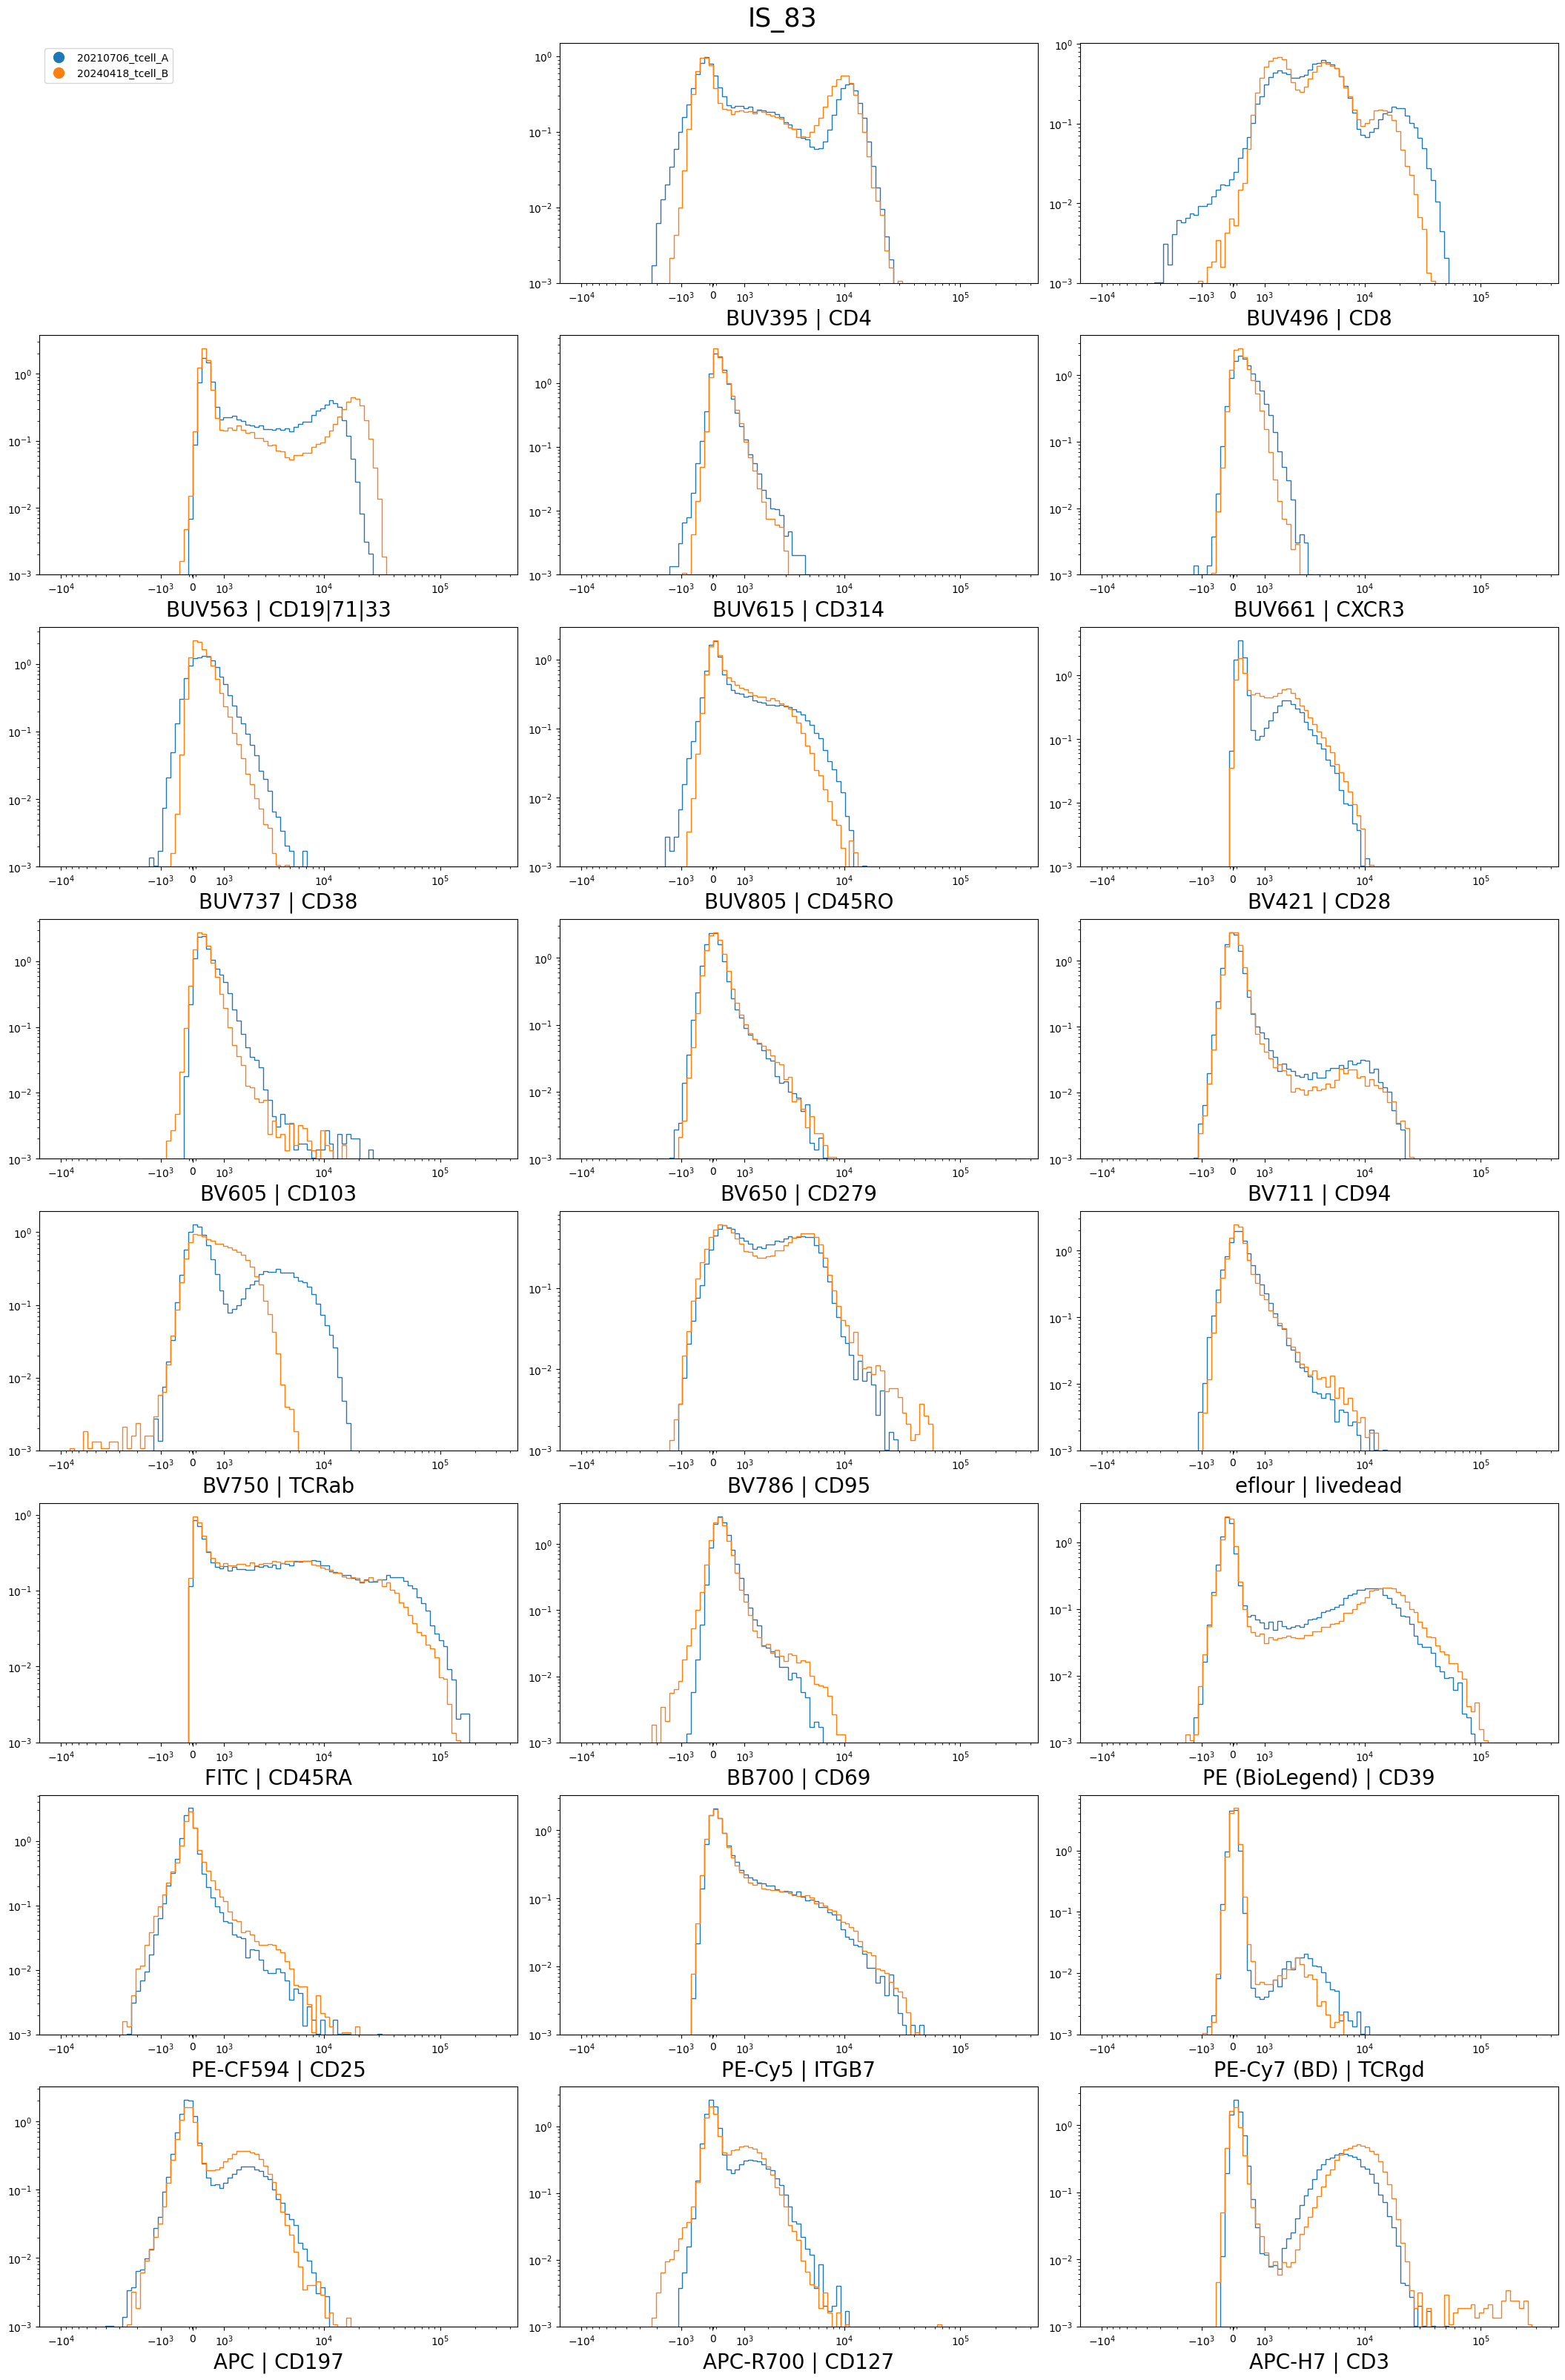

In [21]:
cytovanni.ref.plot_eval_histogram(adatas, "unmx_init", 'IS_83', "ovlp_uid", key_color="batch_ref", xlim=[-1e4, 3e5], ylim=[1e-3,None], savepath="", log=True)

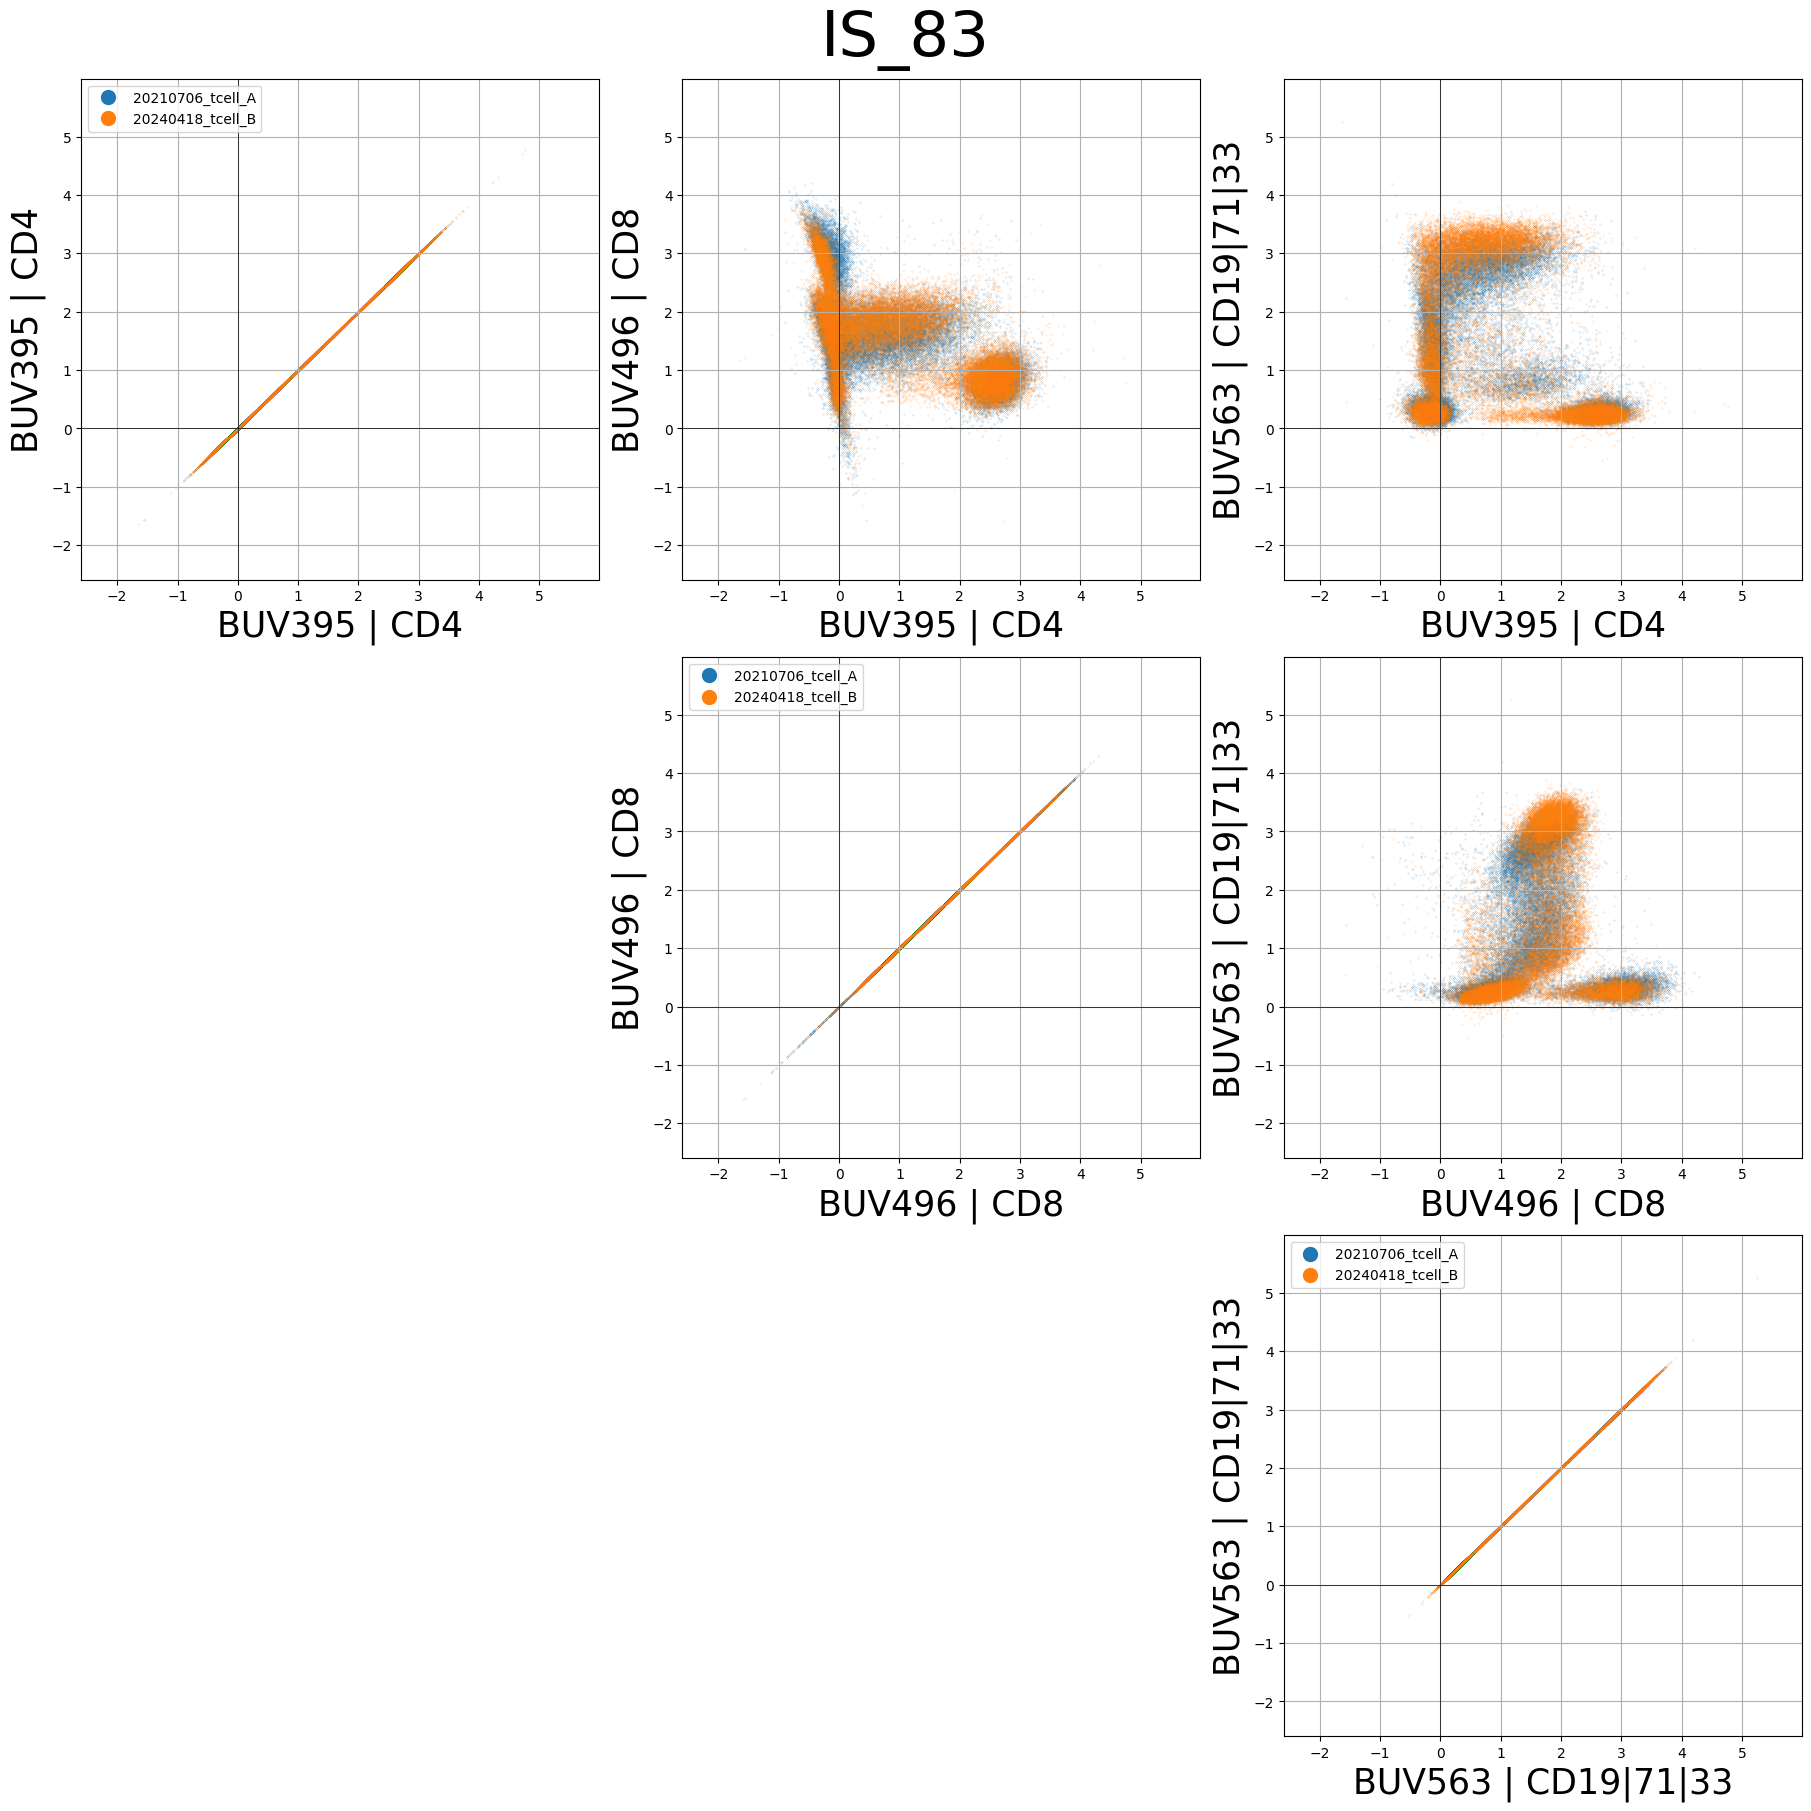

In [35]:
cytovanni.ref.plot_eval_NxN(adatas, "unmx_standardised", 'IS_83', "ovlp_uid", key_color="batch_ref", axlim=[-1e4, 3e5], savepath="", datashader=False)

## Find Missing Components

We also have a panel config where we intentionally dropped PC0 of BUV496. Training with that configuration:

In [21]:
pem_modified = cytovanni.ref.PanelEmbeddingModule.from_data(panelconfig_modified, moe, key_comp_batch,
                                                            batch_order=batch_order, anchor_bidx=anchor_bidx,
                                                            fixed_init="HD7_Compensation_20240418_tcell", max_abs_embedding=6).to(device)
transformer_modified = cytovanni.ref.SpectralFitTransformer.from_data(moe, pem_modified,
                                                                      scale_stains=scale_stains,
                                                                      key_scale_stains="batch", # batch to use for marker scaling factors
                                                                      arcsinh_cofactor=5000, # arcsinh cofactor to use during the fit, set this to higher than what you would normally use for visualization
                                                                      L1weight_embedding=2e-7, L1weight_stainscale=1e-7, L1weight_channelscale=1e-7,
                                                                      anchor_bidx=anchor_bidx)
sfm_modified = cytovanni.ref.OverlapFitModel.from_data(moe, transformer_modified, dataset, DDIST_mode="sinkhorn", DDIST_kwargs={"blur":.5, "reach":1.}).to(device)

In [22]:
sfm_modified.fit(Niter=1500, lr=2e-2)

Overlap Fit: 100%|██████████| 1500/1500 [51:32<00:00,  2.06s/it, LOSS=0.0710, DDIST=0.0710]


In [23]:
from pathlib import Path
Path(os.path.join(data_path, "integration")).mkdir(parents=True, exist_ok=True)
sfm_modified.save(os.path.join(data_path, "integration", "final_model_modified.pt"))

We generate the same evaluation plots as before:

In [15]:
sfm_modified = cytovanni.ref.OverlapFitModel.from_saved(os.path.join(data_path, "integration", "final_model_modified.pt")).to(device)
for ad in tqdm(adatas):
    sfm_modified.add_ad_standardised(ad, key_layer="raw", addkey="unmx_modified")

100%|██████████| 199/199 [00:08<00:00, 24.46it/s]


In [18]:
evaluate_fit(os.path.join(data_path, "eval_model_modified"), adatas_ref_test, adatas_sample_test, "unmx_modified", addname="_test", axlim=[-1e4,3e5], anchor_batch='18-APR-2024')

100%|██████████| 3/3 [09:54<00:00, 198.05s/it]


In [ ]:
evaluate_fit(os.path.join(data_path, "eval_model_modified"), adatas_ref_train, adatas_sample_train, "unmx_modified", addname="_train", axlim=[-1e4,3e5], anchor_batch='18-APR-2024')